## **CQF Exam 3**

# **(I) Project Objectives**
<p>
The objective of this project is to develop a model to predict positive market moves on SPDR Gold Shares (Ticker: GLD) using Machine Learning (ML) techniques.
</p>

<p>
GLD is one of the largest exchange-traded funds (ETF) by asset under management (AUM), designed to track the spot price of physical gold. It was selected for several reasons: the ETF has two decades of trading history with ample data availability, maintains a high daily transaction volume, and its underlying asset is sensitive to macroeconomic factors — making it a strong candidate for ML classification with rich features to explore.
</p>
<p>
A five-year horizon from 2020-01-01 to 2025-12-31 is used, covering multiple macroeconomic regimes including the COVID-19 crash, the zero-rate era, the aggressive rate-hike cycle and the subsequent policy pivot.
</p>
<p>
Short-term asset returns are typically characterized by low-signal to noise ratios, potentially filled with small near-zero returns. Overfitting is therefore key risk, and XGBoost addresses this issue by incorporating a regularized objective function which combines the training loss with explicit penalties on tree structure (γ) and leaf weights (λ), discouraging the model from memorizing the noise in training data. XGBoost also has built-in early stopping, parallel tree construction and ability to handle missing values, making it a well-suited for multi-sourced, large feature sets which will be used in this study.
</p>
<p>
The success criteria is to maximize ROC-AUC. The model will also be evaluated using the F1 score, confusion matrix, and full classification report to identify optimal model parameters. The practical aim is to produce a model that achieves classification accuracy above 50% and generates tradable signals with potential for positive returns after deducting transaction costs.
</p>

## **A) Explanation of Entropy in Classification**
<p>
What does entropy reveal about the quality of the partitions in a classifiation problem?
</p>

Entropy measures the impurity or uncertainty of a partition in a classification problem. The formula is:

$$H(S) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

where:
- $C$ = number of classes
- $p_i$ = proportion of observations in class $i$ inside the partition
- $\log_2$ means log base 2
<br>
<p>
For binary classification, where classes are 0 and 1:
</p>
$$H(S) = -p \log_2(p) - (1-p) \log_2(1-p)$$
<br>
where $p$ is the proportion of class 1, and $1-p$ is the proportion of class 0.
<br>
<p>
A pure partition, where all observations belong to one class, entropy equal to zero because the partition is perfectly pure. At the other extreme is when entropy is at max where observations and its split is basically 50/50. </p><br>

| Class mix in partition | Entropy | Meaning |
|:---|:---|:---|
| 100% / 0% i.e. $-1.0\log_2(1.0) - 0\log_2(0)$ | 0 | Pure |
| 90% / 10% i.e. $-0.9\log_2(0.9) - 0.1\log_2(0.1)$ | 0.469 | Mostly pure |
| 70% / 30% i.e. $-0.7\log_2(0.7) - 0.3\log_2(0.3)$ | 0.881 | Some impurity |
| 50% / 50% i.e. $-0.5\log_2(0.5) - 0.5\log_2(0.5)$ | 1.000 | Most impure |

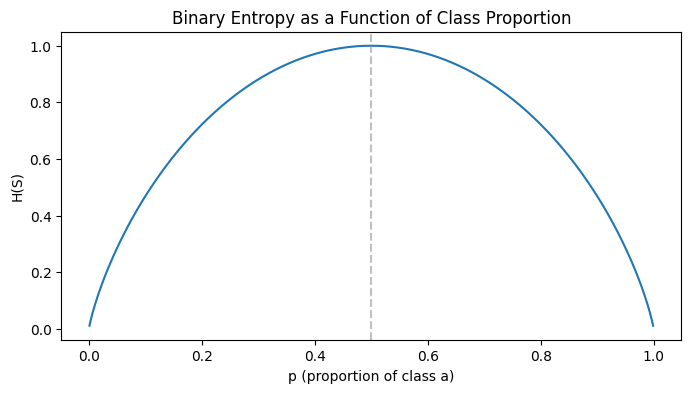

In [3]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.001, 0.999, 500)
H = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

plt.figure(figsize=(8, 4))
plt.plot(p, H)
plt.xlabel('p (proportion of class a)')
plt.ylabel('H(S)')
plt.title('Binary Entropy as a Function of Class Proportion')
plt.axvline(x=0.5, linestyle='--', color='grey', alpha=0.5)
plt.show()

(a) High entropy means the partitions are pure - **False**
<p>
High entropy in this scenario would mean in the binary classification, classes (0, 1) are almost evenly split, meaning we are uncertain which class an observation should belong to, it is impure. </p>

(b) High entropy means the partitions are impure - **True**
<p>
As we just walked through in the above where high entropy is where classes (0, 1) is observed in different classes. Maximum entropy occurs when classes are evenly split and that signals partitions are impure. A good decision-tree split should reduce entropy in the child nodes, producing higher information gain. The information gain formula is defined as follow:
</p>

$$IG = H(\text{parent}) - \frac{|S_L|}{|S|} H(S_L) - \frac{|S_R|}{|S|} H(S_R)$$

<p>
At every tree split, the algorithm aims to select a split that maximizes IG, driving child nodes toward lower entropy (purer partitions).
</p>

<p>
Applying this to the GLD price direction prediction, each split with XGBoost will seek to separate positive-move days from negative-move days as cleanly as possible, reducing entropy at each node.
</p>


## **(II) Data Collection**

A range of factors impact spot gold and GLD price. Broadly, these are the key categories:

1) Macroeconomic Factors – economic cycles, inflation expectations, central bank reserves and policies, credit conditions

2) Yields/ Currency – policy rates (fed funds), treasury yields across the curve(real and nominal), yield curve shape, USD index, especially majority of gold is transacted in USD

3) Asset Price, Cross-Asset and Positioning – GLD technicals (e.g. momentum, volatility, transaction volume, Bollinger Bands), gold to silver ratio, gold miner (GDX), equity index (SPY), bond ETFs (TLT), options/ futures position (speculative positioning from CFTC COT data)

4) Geopolitics and Risk Sentiment – VIX, equities drawdown, credit spreads (as proxy for market stress), war (e.g. Ukraine, Iran war), central bank policies (often country specific, geopolitical decision to increase gold holdings as a hedge or reserve)

Not all factors are accessible from public data sources, nor are they suitable. For example, certain gold price drivers such as wars, sanctions, central bank policy shifts are one-off/ structural change in nature; supply-side dynamics (e.g. miners output, refinery capacity) impact a much longer horizon. These are either too low in frequency or too lagged for daily directional classification or one-off events which is difficult to model. Therefore we will focus on extracting data from public sources such as Yahoo Finance, Federal Reserve Bank of St. Louis (FRED) and CFTC Commitments of Traders (COT).

Data extraction will cover approximately 5 years, aiming to ensure multiple market regimes are covered (COVID crisis, zero rate period, rate hike cycle, subsequent pivot). Data will be extracted for factors believed to impact the underlying asset, with features to be engineered after data extraction, initial EDA but before funneling into a more realistic features pipeline.


Full feature list includes:

| Source | Series | Description | Theme |
|:-------|:-------|:------------|:------|
| Yahoo Finance | GLD | SPDR Gold Shares ETF (OHLCV) | Underlying |
| | SLV | iShares Silver Trust | Cross-asset |
| | GDX | VanEck Gold Miners ETF | Cross-asset |
| | TLT | iShares 20+ Year Treasury Bond | Yields |
| | SPY | S&P 500 ETF | Risk sentiment |
| FRED | DGS10 | 10-Year Treasury yield | Yields |
| | DFII10 | 10-Year TIPS yield (real) | Yields |
| | T10YIE | 10-Year breakeven inflation | Macro |
| | T10Y2Y | 10Y–2Y yield curve spread | Yields |
| | DFF | Federal funds effective rate | Macro |
| | DTWEXBGS | Broad trade-weighted USD index | Currency |
| | VIXCLS | CBOE VIX | Risk sentiment |
| | BAMLC0A0CM | ICE BofA US corporate spread | Risk sentiment |
| | DCOILWTICO | WTI crude oil price | Macro |
| CFTC COT | Gold futures | Spec long/short, commercial, OI | Positioning |

**a) Install Packages & Import Libraries**

In [4]:
# Install packages
# !pip install -q cot_reports yfinance fredapi
# !pip install -q xgboost wandb pyfolio-reloaded

In [5]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/CQF")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# For data wrangling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For features data extraction
import yfinance as yf
from fredapi import Fred
from cot_reports import cot_year

**b) Data Extraction**

i) Yahoo Finance

In [7]:
# Data Extraction from Yahoo Finance

# Define tickers and date range
tickers     = ['GLD', 'SLV', 'GDX', 'TLT', 'SPY']
start_date  = '2019-12-01'  # buffer before 2020-01-01 for rolling window warmup
end_date    = '2025-12-31'

# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# GLD: full Adjusted OHLCV (needed for technical features)
df_gld = yf.download('GLD', start=start_date, end=end_date, auto_adjust=True, progress=False)
df_gld.columns = [f'GLD_{col}' for col in df_gld.columns.get_level_values('Price')]

# Cross-asset tickers: Adjusted Close only
cross_tickers = ['SLV', 'GDX', 'TLT', 'SPY']
df_cross = yf.download(cross_tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)['Close']
df_cross.columns = [f'{col}_Close' for col in df_cross.columns]

# Merge into one flat DataFrame and save to google drive
df_yf = pd.concat([df_gld, df_cross], axis=1)
df_yf.to_csv(os.path.join(SAVE_PATH, 'raw_yfinance.csv'))

In [8]:
# High level Data Quality Check
print(f"Shape: {df_yf.shape}")
print(f"Date range: {df_yf.index.min()} to {df_yf.index.max()}")
print(f"\nMissing values:\n{df_yf.isnull().sum()}")

Shape: (1528, 9)
Date range: 2019-12-02 00:00:00 to 2025-12-30 00:00:00

Missing values:
GLD_Close     0
GLD_High      0
GLD_Low       0
GLD_Open      0
GLD_Volume    0
GDX_Close     0
SLV_Close     0
SPY_Close     0
TLT_Close     0
dtype: int64


In [9]:
print(f"\nColumns: {df_yf.columns.tolist()}")
df_yf.head()


Columns: ['GLD_Close', 'GLD_High', 'GLD_Low', 'GLD_Open', 'GLD_Volume', 'GDX_Close', 'SLV_Close', 'SPY_Close', 'TLT_Close']


,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close
Date,,,,,,,,,
2019-12-02,137.789993,138.089996,137.300003,137.320007,8274700,25.041309,15.800000,283.404297,114.642311
2019-12-03,139.110001,139.570007,138.970001,139.039993,8481700,25.594301,16.049999,281.503693,117.046043
2019-12-04,138.919998,139.169998,138.589996,139.160004,6322300,25.327021,15.760000,283.240570,115.877373
2019-12-05,139.000000,139.449997,138.789993,138.800003,5671500,25.456055,15.850000,283.749847,115.313759
2019-12-06,137.619995,137.830002,137.399994,137.759995,8714500,24.856977,15.480000,286.341644,114.675507


ii) FRED

In [10]:
# FRED API key from Colab Secrets
from google.colab import userdata
fred = Fred(api_key=userdata.get('FRED'))

# Date Parameters
start_date = '2019-12-01'
end_date = '2025-12-31'

# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# Define FRED series
fred_series = {
    'DGS10':      '10-Year Treasury Yield',
    'DFII10':     '10-Year TIPS (Real Yield)',
    'T10YIE':     '10-Year Breakeven Inflation',
    'T10Y2Y':     'Yield Curve (10Y-2Y)',
    'DFF':        'Fed Funds Effective Rate',
    'DTWEXBGS':   'Broad Trade-Weighted USD Index',
    'VIXCLS':     'CBOE VIX',
    'BAMLC0A0CM': 'ICE BofA US Corporate Spread',
    'DCOILWTICO': 'WTI Crude Oil',
}

# Download each series
df_fred = pd.DataFrame()
for code, desc in fred_series.items():
    try:
        s = fred.get_series(code, observation_start=start_date, observation_end=end_date)
        df_fred[code] = s
    except Exception as e:
        print(f"  {code:15s} FAILED: {e}")

df_fred.to_csv(os.path.join(SAVE_PATH, 'raw_fred.csv'))

In [11]:
# High level Data Quality Check
print(f"\nShape: {df_fred.shape}")
print(f"Date range: {df_fred.index.min()} to {df_fred.index.max()}")
print(f"\nMissing values:\n{df_fred.isnull().sum()}")


Shape: (1588, 9)
Date range: 2019-12-02 00:00:00 to 2025-12-31 00:00:00

Missing values:
DGS10          67
DFII10         67
T10YIE         67
T10Y2Y         67
DFF             0
DTWEXBGS       69
VIXCLS         32
BAMLC0A0CM    913
DCOILWTICO     67
dtype: int64


In [12]:
print(f"\nColumns: {df_fred.columns.tolist()}")
display(df_fred.head())


Columns: ['DGS10', 'DFII10', 'T10YIE', 'T10Y2Y', 'DFF', 'DTWEXBGS', 'VIXCLS', 'BAMLC0A0CM', 'DCOILWTICO']


,DGS10,DFII10,T10YIE,T10Y2Y,DFF,DTWEXBGS,VIXCLS,BAMLC0A0CM,DCOILWTICO
2019-12-02,1.83,0.18,1.65,0.22,1.56,116.9647,14.91,NaN,55.97
2019-12-03,1.72,0.09,1.63,0.19,1.55,116.8898,15.96,NaN,56.15
2019-12-04,1.77,0.11,1.66,0.19,1.55,116.6920,14.80,NaN,58.46
2019-12-05,1.80,0.13,1.67,0.22,1.55,116.3838,14.52,NaN,58.42
2019-12-06,1.84,0.15,1.69,0.23,1.55,116.5381,13.62,NaN,59.20


iii) CFTC COT

In [13]:
# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# Columns to keep and their clean names
cot_cols = {
    'Open Interest (All)'                 :'COT_OI',
    'Noncommercial Positions-Long (All)'  :'COT_Spec_Long',
    'Noncommercial Positions-Short (All)' :'COT_Spec_Short',
    'Commercial Positions-Long (All)'     :'COT_Comm_Long',
    'Commercial Positions-Short (All)'    :'COT_Comm_Short',
}

# Download, filter Gold, select columns
# date range to extract reports
years = range(2019, 2026)

frames = []
for year in years:
    df = cot_year(year, cot_report_type='legacy_fut')
    gold = df[df['Market and Exchange Names'].str.contains('GOLD', case=False)]
    frames.append(gold)

df_cot_gold = (
    pd.concat(frames, ignore_index=True)
    .assign(Date=lambda d: pd.to_datetime(d['As of Date in Form YYYY-MM-DD']))
    .set_index('Date')
    .sort_index()
    [list(cot_cols.keys())]
    .rename(columns=cot_cols)
    .apply(pd.to_numeric, errors='coerce')
)

df_cot_gold.to_csv(os.path.join(SAVE_PATH, 'raw_cot_gold.csv'))

Selected: legacy_fut
Downloaded single year data from: 2019
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2020
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2021
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2022
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2023
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2024
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2025
Stored the file annual.txt in the working directory.


In [14]:
# High level Data Quality Check
print(f"\nShape: {df_cot_gold.shape}")
print(f"Date range: {df_cot_gold.index.min()} to {df_cot_gold.index.max()}")
print(f"\nMissing values:\n{df_cot_gold.isnull().sum()}")


Shape: (492, 5)
Date range: 2019-01-08 00:00:00 to 2025-12-30 00:00:00

Missing values:
COT_OI            0
COT_Spec_Long     0
COT_Spec_Short    0
COT_Comm_Long     0
COT_Comm_Short    0
dtype: int64


In [15]:
df_cot_gold.head()

,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,
2019-01-08,455232,199560,100344,137605,258792
2019-01-15,501605,201796,113883,179059,287172
2019-01-22,513509,186510,112006,197278,289355
2019-01-29,483390,212318,112725,163922,282531
2019-02-05,479736,218200,109105,157588,288830


c) Data Cleaning

i) Examining NAN values in FRED df

At a first pass, FRED data has NAN values, with BAMLC0A0CM (credit Spread) missing 900+ bars. Investigation required.

In [16]:
print("\nSample of NaN dates across yield series:")
nan_dates = df_fred[df_fred['DGS10'].isnull()].index[:10]
print(nan_dates)

print("\n\nBAMLC0A0CM (credit spread) — first valid date:")
df_fred['BAMLC0A0CM'].first_valid_index()




Sample of NaN dates across yield series:
DatetimeIndex(['2019-12-25', '2020-01-01', '2020-01-20', '2020-02-17',
               '2020-04-10', '2020-05-25', '2020-07-03', '2020-09-07',
               '2020-10-12', '2020-11-11'],
              dtype='datetime64[ns]', freq=None)


BAMLC0A0CM (credit spread) — first valid date:


Timestamp('2023-05-22 00:00:00')

On FRED NAN dates - dates listed above, are non-trading days. This will be adjsuted with ffill, same process for other data sources. <br>

Re BAMLC0A0CM (Credit spread), this data series it not usable for ML training as there is insufficient data, earliest start date only in 2023-05-22 leaving us 2.5 years of data for training and testing. <br>

ICE BofA US High Yield Index Option-Adjusted Spread data has been explored as an alternative. However, we encountered same issue where earliest data availability only starts from 2023-05. <br>

Conclusion: BAMLC0A0CM is dropped from the FRED dataset and replaced with Moody's BAA Corporate Bond Yield (DBAA), The credit spread will become an engineered feature using BAA yield minus 10-Year Treasury. This will be addressed in the feature engineering process.


In [17]:
# Replace credit spread series with Moody's BAA yield
df_fred = df_fred.drop(columns=['BAMLC0A0CM'])
df_fred['DBAA'] = fred.get_series('DBAA', observation_start='2019-12-01', observation_end='2025-12-31')

print(f"Shape: {df_fred.shape}")
print(f"\nMissing values:\n{df_fred.isnull().sum()}")

Shape: (1588, 9)

Missing values:
DGS10         67
DFII10        67
T10YIE        67
T10Y2Y        67
DFF            0
DTWEXBGS      69
VIXCLS        32
DCOILWTICO    67
DBAA          68
dtype: int64


In [18]:
print(f"Duplicate dates: {df_cot_gold.index.duplicated().sum()}")
print(f"\nDuplicate rows:")
display(df_cot_gold[df_cot_gold.index.duplicated(keep=False)].head(10))

Duplicate dates: 127

Duplicate rows:


,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,
2020-12-01,32377,15096,13979,0,0
2020-12-01,538042,324344,64030,110108,403371
2020-12-29,556414,341812,72940,101283,408537
2020-12-29,34210,15798,22384,0,0
2021-05-18,33854,10031,12915,0,0
2021-05-18,520410,290267,91378,121839,354740
2021-08-17,485485,284437,92895,123301,337301
2021-08-17,32480,14107,8528,0,0
2021-09-07,34633,8491,9756,0,0


ii) merge all df together for further data cleaning and pre-processing

In [19]:
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data/'

# Load raw data
# df_yf = pd.read_csv(SAVE_PATH + 'raw_yfinance.csv', index_col=0, parse_dates=True)
# df_fred = pd.read_csv(SAVE_PATH + 'raw_fred.csv', index_col=0, parse_dates=True)
# df_cot = pd.read_csv(SAVE_PATH + 'raw_cot_gold.csv', index_col=0, parse_dates=True)

# Step 1: GLD trading dates = master calendar
master_idx = df_yf.index

# Step 2: Reindex FRED to GLD calendar, forward-fill
df_fred_aligned = df_fred.reindex(master_idx).ffill()

# Step 3: Reindex COT to GLD calendar, forward-fill
# Remove duplicate dates (aggregate if multiple gold contracts per week)
df_cot_dedup = df_cot_gold.groupby(df_cot_gold.index).sum()

# COT is Tuesday snapshot, published Friday — shift forward 4 business days
# so the model first sees it on the following Monday (no lookahead bias)
df_cot_aligned = (
    df_cot_dedup
    .shift(freq=pd.tseries.offsets.BDay(4))  # Tue → next Mon
    .reindex(master_idx)
    .ffill()
)

# Step 4: Merge all into one DataFrame
df_merged = pd.concat([df_yf, df_fred_aligned, df_cot_aligned], axis=1)

In [20]:
# High level data audit
print(f"Shape: {df_merged.shape}")
print(f"Date range: {df_merged.index.min()} to {df_merged.index.max()}")
print(f"\nMissing values:\n{df_merged.isnull().sum()}")
print(f"\nTotal NaN: {df_merged.isnull().sum().sum()}")

Shape: (1528, 23)
Date range: 2019-12-02 00:00:00 to 2025-12-30 00:00:00

Missing values:
GLD_Close         0
GLD_High          0
GLD_Low           0
GLD_Open          0
GLD_Volume        0
GDX_Close         0
SLV_Close         0
SPY_Close         0
TLT_Close         0
DGS10             0
DFII10            0
T10YIE            0
T10Y2Y            0
DFF               0
DTWEXBGS          0
VIXCLS            0
DCOILWTICO        0
DBAA              0
COT_OI            0
COT_Spec_Long     0
COT_Spec_Short    0
COT_Comm_Long     0
COT_Comm_Short    0
dtype: int64

Total NaN: 0


In [21]:
df_merged.head()

,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close,DGS10,...,DFF,DTWEXBGS,VIXCLS,DCOILWTICO,DBAA,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,,,,,,,,,,,,,,,,,
2019-12-02,137.789993,138.089996,137.300003,137.320007,8274700,25.041309,15.800000,283.404297,114.642311,1.83,...,1.56,116.9647,14.91,55.97,3.94,669268.0,325286.0,53652.0,191548.0,497015.0
2019-12-03,139.110001,139.570007,138.970001,139.039993,8481700,25.594301,16.049999,281.503693,117.046043,1.72,...,1.55,116.8898,15.96,56.15,3.83,669268.0,325286.0,53652.0,191548.0,497015.0
2019-12-04,138.919998,139.169998,138.589996,139.160004,6322300,25.327021,15.760000,283.240570,115.877373,1.77,...,1.55,116.6920,14.80,58.46,3.88,669268.0,325286.0,53652.0,191548.0,497015.0
2019-12-05,139.000000,139.449997,138.789993,138.800003,5671500,25.456055,15.850000,283.749847,115.313759,1.80,...,1.55,116.3838,14.52,58.42,3.89,669268.0,325286.0,53652.0,191548.0,497015.0
2019-12-06,137.619995,137.830002,137.399994,137.759995,8714500,24.856977,15.480000,286.341644,114.675507,1.84,...,1.55,116.5381,13.62,59.20,3.91,669268.0,325286.0,53652.0,191548.0,497015.0


In [22]:
# Sanity check if there are 0 left in columns
print("Zero counts per column:")
print((df_merged == 0).sum())
print(f"\nDescriptive stats:")
display(df_merged.describe().T)

Zero counts per column:
GLD_Close         0
GLD_High          0
GLD_Low           0
GLD_Open          0
GLD_Volume        0
GDX_Close         0
SLV_Close         0
SPY_Close         0
TLT_Close         0
DGS10             0
DFII10            4
T10YIE            0
T10Y2Y            4
DFF               0
DTWEXBGS          0
VIXCLS            0
DCOILWTICO        0
DBAA              0
COT_OI            0
COT_Spec_Long     0
COT_Spec_Short    0
COT_Comm_Long     0
COT_Comm_Short    0
dtype: int64

Descriptive stats:


,count,mean,std,min,25%,50%,75%,max
GLD_Close,1528.0,2.025948e+02,5.820279e+01,1.375800e+02,1.672675e+02,1.785250e+02,2.194700e+02,4.167400e+02
GLD_High,1528.0,2.034868e+02,5.849139e+01,1.378100e+02,1.679400e+02,1.792450e+02,2.206200e+02,4.184500e+02
GLD_Low,1528.0,2.015771e+02,5.774575e+01,1.361200e+02,1.666700e+02,1.778850e+02,2.177575e+02,4.147500e+02
GLD_Open,1528.0,2.025812e+02,5.817964e+01,1.373200e+02,1.673600e+02,1.787100e+02,2.193100e+02,4.164800e+02
GLD_Volume,1528.0,9.111959e+06,5.369983e+06,1.436500e+06,5.777175e+06,7.735600e+06,1.073100e+07,6.202500e+07
GDX_Close,1528.0,3.528770e+01,1.211298e+01,1.763556e+01,2.849683e+01,3.195641e+01,3.678252e+01,9.129000e+01
SLV_Close,1528.0,2.424166e+01,7.302573e+00,1.121000e+01,2.068750e+01,2.254000e+01,2.643000e+01,7.112000e+01
SPY_Close,1528.0,4.374444e+02,1.092323e+02,2.049449e+02,3.656015e+02,4.141663e+02,5.212864e+02,6.884997e+02
TLT_Close,1528.0,1.030292e+02,2.008556e+01,7.426585e+01,8.587150e+01,9.281936e+01,1.223608e+02,1.437899e+02
DGS10,1528.0,2.939090e+00,1.403872e+00,5.200000e-01,1.550000e+00,3.540000e+00,4.200000e+00,4.980000e+00


In [23]:
# save merged file to data folder
df_merged.to_csv(os.path.join(SAVE_PATH, 'cleaned_merged.csv'))

## **(III) EDA**

In [24]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/cleaned_merged.csv', index_col=0, parse_dates=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: (1528, 23)
Date range: 2019-12-02 00:00:00 to 2025-12-30 00:00:00
Missing values: 0


,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close,DGS10,...,DFF,DTWEXBGS,VIXCLS,DCOILWTICO,DBAA,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,,,,,,,,,,,,,,,,,
2019-12-02,137.789993,138.089996,137.300003,137.320007,8274700,25.041309,15.800000,283.404297,114.642311,1.83,...,1.56,116.9647,14.91,55.97,3.94,669268.0,325286.0,53652.0,191548.0,497015.0
2019-12-03,139.110001,139.570007,138.970001,139.039993,8481700,25.594301,16.049999,281.503693,117.046043,1.72,...,1.55,116.8898,15.96,56.15,3.83,669268.0,325286.0,53652.0,191548.0,497015.0
2019-12-04,138.919998,139.169998,138.589996,139.160004,6322300,25.327021,15.760000,283.240570,115.877373,1.77,...,1.55,116.6920,14.80,58.46,3.88,669268.0,325286.0,53652.0,191548.0,497015.0
2019-12-05,139.000000,139.449997,138.789993,138.800003,5671500,25.456055,15.850000,283.749847,115.313759,1.80,...,1.55,116.3838,14.52,58.42,3.89,669268.0,325286.0,53652.0,191548.0,497015.0
2019-12-06,137.619995,137.830002,137.399994,137.759995,8714500,24.856977,15.480000,286.341644,114.675507,1.84,...,1.55,116.5381,13.62,59.20,3.91,669268.0,325286.0,53652.0,191548.0,497015.0


In [25]:
# Descriptive statistics
df.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
GLD_Close,1528.00,202.59,58.20,137.58,167.27,178.52,219.47,416.74
GLD_High,1528.00,203.49,58.49,137.81,167.94,179.24,220.62,418.45
GLD_Low,1528.00,201.58,57.75,136.12,166.67,177.88,217.76,414.75
GLD_Open,1528.00,202.58,58.18,137.32,167.36,178.71,219.31,416.48
GLD_Volume,1528.00,9111959.49,5369982.69,1436500.00,5777175.00,7735600.00,10731000.00,62025000.00
GDX_Close,1528.00,35.29,12.11,17.64,28.50,31.96,36.78,91.29
SLV_Close,1528.00,24.24,7.30,11.21,20.69,22.54,26.43,71.12
SPY_Close,1528.00,437.44,109.23,204.94,365.60,414.17,521.29,688.50
TLT_Close,1528.00,103.03,20.09,74.27,85.87,92.82,122.36,143.79
DGS10,1528.00,2.94,1.40,0.52,1.55,3.54,4.20,4.98


Descriptive statistics are revealing vastly different scales across the raw columns - from single digit yields percentages to trading volume in millions. This confirms that raw features will need to be transformed, normalized and engineered.

In [28]:
# Verify continuous trading day index (no unexpected gaps)
date_diffs = df.index.to_series().diff().dt.days
print(f"Min gap: {date_diffs.min()} days")
print(f"Max gap: {date_diffs.max()} days")
print(f"\nGap distribution:\n{date_diffs.value_counts().sort_index()}")

Min gap: 1.0 days
Max gap: 4.0 days

Gap distribution:
Date
1.0    1194
2.0      16
3.0     274
4.0      43
Name: count, dtype: int64


A date continuity check confirms no unexpected gaps in the trading day index — observed gaps of 1 to 4 calendar days correspond to weekday, weekend, and holiday patterns.

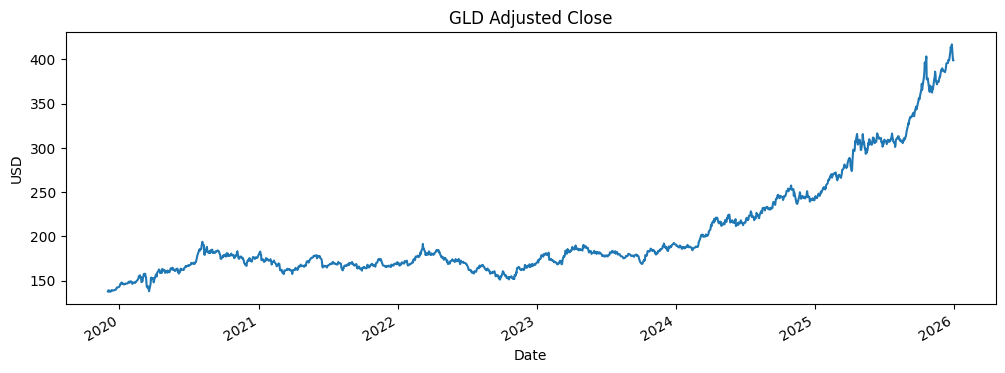

In [45]:
# GLD price history
df['GLD_Close'].plot(figsize=(12, 4), title='GLD Adjusted Close')
plt.ylabel('USD')
plt.show()

GLD has shown an upward trend, paritulcalry from mid-2024 onward. This long bias may result in a class imbalance toward positive returns, which will be examined during label construction.

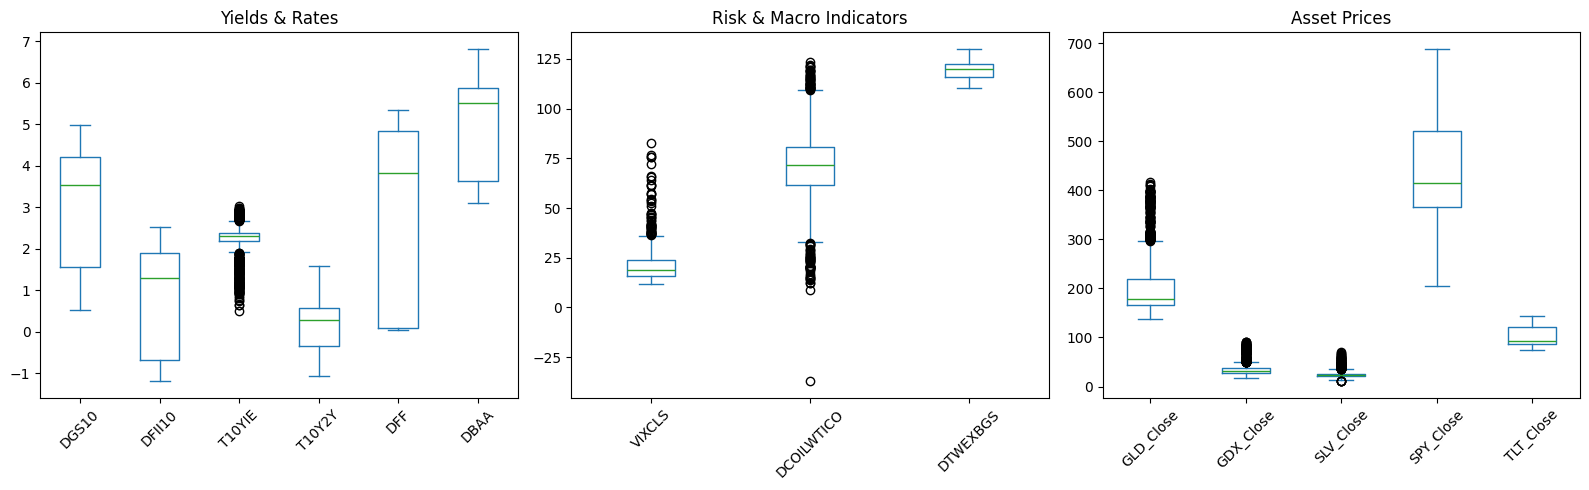

In [34]:
# Box plots — grouped by scale
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Yields & rates
df[['DGS10', 'DFII10', 'T10YIE', 'T10Y2Y', 'DFF', 'DBAA']].plot.box(ax=axes[0])
axes[0].set_title('Yields & Rates')
axes[0].tick_params(axis='x', rotation=45)

# Risk & macro
df[['VIXCLS', 'DCOILWTICO', 'DTWEXBGS']].plot.box(ax=axes[1])
axes[1].set_title('Risk & Macro Indicators')
axes[1].tick_params(axis='x', rotation=45)

# GLD OHLC only (not volume, not cross-asset)
df[['GLD_Close', 'GDX_Close', 'SLV_Close', 'SPY_Close', 'TLT_Close']].plot.box(ax=axes[2])
axes[2].set_title('Asset Prices')
# df[['GLD_Open', 'GLD_High', 'GLD_Low', 'GLD_Close']].plot.box(ax=axes[2])
# axes[2].set_title('GLD Price')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The box plots revealed notable outliers in VIX and Oil (COVID-er spike and WTI going negative in 2020). The assets – GLD, GDX, SLV all showing wide ranges with upper outliers, this matches with price breakthroughs late 2024-2025. SPY’s wide range is a good indicator we have covered different market regimes in the dataset.

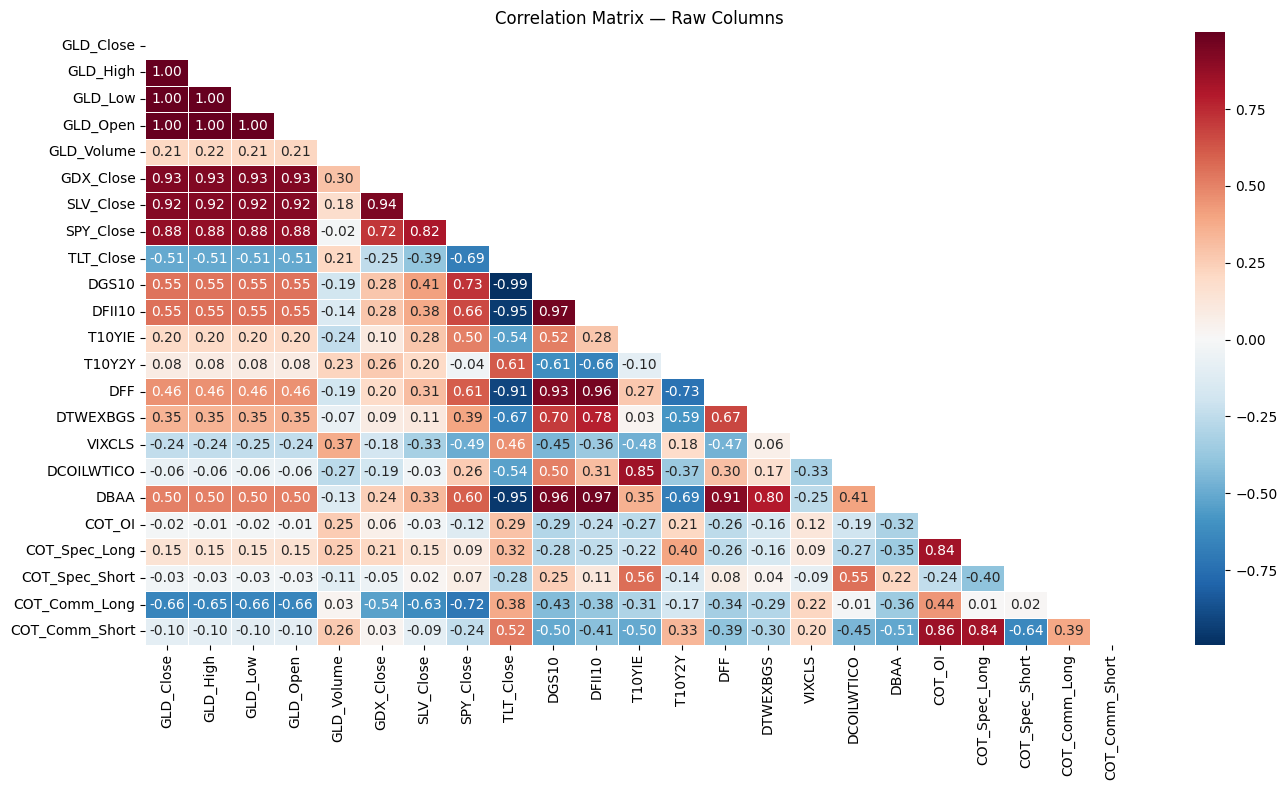

In [44]:
fig, ax = plt.subplots(figsize=(14, 8))
matrix = np.triu(df.corr())
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", linewidths=0.5, ax=ax, mask=matrix)
ax.set_title("Correlation Matrix — Raw Columns")
plt.tight_layout()
plt.show()

The raw column correlation matrix is used as an exploratory diagnostic to understand common trends, potentially redundant variables and macro regimes. At this stage, they may not signal predictive relationships. Several observations:

1) potentially redundant variables – GLD OHLC almost identical, reinforcing the need to convert into ratios, returns, z-scores etc in feature engineering and likely to be dropped afterwards
2) potentially high colinear feature groups – Cross asset ETFs, COT variables, rate variables
3) understanding on broad market structure and relationships – TLT and commercial COT positionings are strongly negatively correlated with GLD price